In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd
from scipy.optimize import minimize

import importlib
import SyntheticPhaseLinearMeasurement as SPLM
importlib.reload(SPLM)

%config InlineBackend.figure_format = 'retina'
cmap = plt.cm.viridis
rng = np.random.default_rng(seed=326890)   # PCG64 by default

## Simulate and Infer

In [15]:
# Prior Hyperparameters 
mu_theta = 0
sigma_theta = 2*np.pi
mu_omega = 1
sigma_omega = 1
alpha_D = 1
beta_D = 2
alpha_R = 0.01
beta_R = 0.01
priors = (mu_theta, sigma_theta, mu_omega, sigma_omega, alpha_D, beta_D, alpha_R, beta_R)

# Model Parameters 
omega = 1.    # drift velocity
Dtheta = 1.   # phase diffusivity 
R = 0.1        # noise variance, radians^2
param = (omega,Dtheta,R)

# Simulation Parameters
N = 100   # number of data points
dt = 1.   # time step
N_samples = 10000
max_iter = 500
tol = 1e-5

In [20]:
lambda_map, lambda_cov, em_rate = SPLM.simulate_and_infer(param, N, dt, rng, priors, 
                                                 N_samples=N_samples, max_iter=max_iter, tol=tol)

print(f'convergence steps = {1/em_rate:.5f}')
print(f'phase velocity = {lambda_map[0]:.5f} +/- {np.sqrt(lambda_cov[0,0]):.5f}')
print(f'log diffusivity = {np.log(lambda_map[1]):.5f} +/- {np.sqrt(lambda_cov[1,1]):.5f}')
print(f'log noise var = {np.log(lambda_map[2]):.5f} +/- {np.sqrt(lambda_cov[2,2]):.5f}')

convergence steps = 47.48347
phase velocity = 1.07319 +/- 0.13761
log diffusivity = -0.04561 +/- 0.14018
log noise var = -4.63948 +/- 0.96987


## Effect of $N$

For constant $\Delta t$, $\theta_0$, $\omega$, $D_\theta$, $R$. Sweep number of data points from $N_\min$ to $N_\max$.

In [24]:
# Model Parameters 
omega = 1.    # drift velocity
Dtheta = 1.   # phase diffusivity 
R = 1        # noise variance, radians^2
param = (omega,Dtheta,R)

# Simulation Parameters
dt = 1. # time step
N_samples = 1000

N_points = 30
N_min = 10
N_max = 10000
Ns = np.round(np.logspace(np.log10(N_min), np.log10(N_max), N_points)).astype(int)

omegas  = np.zeros((N_points,))
omega_errs  = np.zeros((N_points,))
Dthetas  = np.zeros((N_points,))
lnDtheta_errs  = np.zeros((N_points,))
Rs  = np.zeros((N_points,))
lnR_errs  = np.zeros((N_points,))
em_rates = np.zeros((N_points,))

for j in range(N_points):
    lambda_map, lambda_cov, em_rate = SPLM.simulate_and_infer(param, Ns[j], dt, rng, priors, 
                                                     N_samples=N_samples, max_iter=max_iter, tol=tol)
  
    omegas[j] = lambda_map[0]
    omega_errs[j] = np.sqrt(lambda_cov[0,0])

    Dthetas[j] = lambda_map[1]
    lnDtheta_errs[j] = np.sqrt(lambda_cov[1,1])

    Rs[j] = lambda_map[2]
    lnR_errs[j] = np.sqrt(lambda_cov[2,2])

    em_rates[j] = em_rate

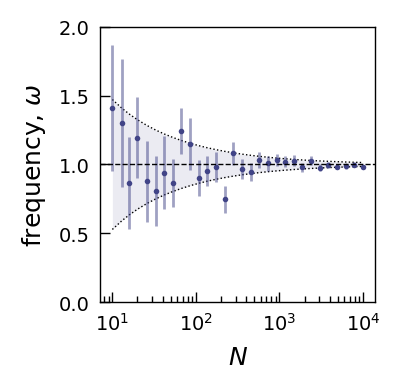

In [350]:
# Desired axes dimensions in centimeters
axes_width_cm = 3.5
axes_height_cm = 3.5

# Convert centimeters to inches (1 inch = 2.54 cm)
axes_width_in = axes_width_cm / 2.54    # ~2.362 in
axes_height_in = axes_height_cm / 2.54  # ~1.772 in

# Define margins for labels/ticks in inches (adjust as needed)
left_margin = 0.5
right_margin = 0.5
bottom_margin = 0.5
top_margin = 0.5

# Overall figure size in inches: axes area plus margins
fig_width = axes_width_in + left_margin + right_margin
fig_height = axes_height_in + bottom_margin + top_margin

# Create figure with computed size
fig = plt.figure(figsize=(fig_width, fig_height))

# Calculate normalized (0-1) coordinates for the axes
left_norm = left_margin / fig_width
bottom_norm = bottom_margin / fig_height
axes_width_norm = axes_width_in / fig_width
axes_height_norm = axes_height_in / fig_height

# Add axes with the computed position; this sets the axes frame to be exactly 6 cm by 4.5 cm.
ax = fig.add_axes([left_norm, bottom_norm, axes_width_norm, axes_height_norm])

# Plot the data
plt.fill_between(Ns, omega + np.sqrt(2*Dtheta/((Ns-1)*dt)), 
                 omega - np.sqrt(2*Dtheta/((Ns-1)*dt)), 
                 color=cmap(0.2), alpha=0.1, lw=0)
plt.plot(Ns, omega + np.sqrt(2*Dtheta/((Ns-1)*dt)), 'k:', lw=0.5)
plt.plot(Ns, omega - np.sqrt(2*Dtheta/((Ns-1)*dt)), 'k:', lw=0.5)

plt.plot(Ns, omegas, 'o', mew=0, ms=2, color=cmap(0.2))
plt.errorbar(Ns, omegas, omega_errs, fmt='None', color=cmap(0.2), lw=1, alpha=0.5)

# prior
# plt.axhline(y=mu_omega - sigma_omega, color='k', lw=0.5, ls='--')
# plt.axhline(y=mu_omega + sigma_omega, color='k', lw=0.5, ls='--')

# true mean
plt.axhline(y=omega, color='k', lw=0.5, ls='--')

# Set axis labels with font size 9 pt
ax.set_ylabel(r'frequency, $\omega$', fontsize=9)
ax.set_xlabel(r'$N$', fontsize=9)
ax.set_xscale('log')
ax.set_ylim(0,2)

# Set tick label fonts to 7 pt, tick mark widths to 0.5 pt, and ticks pointing inward
ax.tick_params(axis='both', which='major', labelsize=7, width=0.5, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=7, width=0.5, direction='in')

# Set the width of the frame (all spines) to 0.5 pt
for spine in ax.spines.values():
    spine.set_linewidth(0.5)


plt.savefig('frequency_vs_N.pdf')

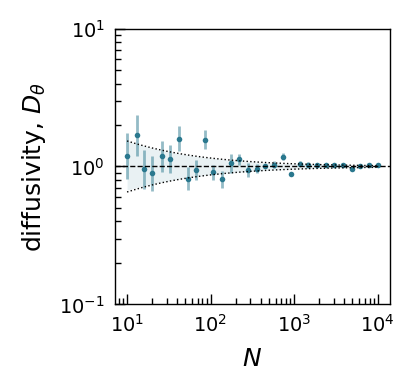

In [351]:
Dtheta_errs = np.vstack((Dthetas - np.exp(np.log(Dthetas) - lnDtheta_errs),
                         np.exp(np.log(Dthetas) + lnDtheta_errs) - Dthetas))


# Desired axes dimensions in centimeters
axes_width_cm = 3.5
axes_height_cm = 3.5

# Convert centimeters to inches (1 inch = 2.54 cm)
axes_width_in = axes_width_cm / 2.54    # ~2.362 in
axes_height_in = axes_height_cm / 2.54  # ~1.772 in

# Define margins for labels/ticks in inches (adjust as needed)
left_margin = 0.5
right_margin = 0.5
bottom_margin = 0.5
top_margin = 0.5

# Overall figure size in inches: axes area plus margins
fig_width = axes_width_in + left_margin + right_margin
fig_height = axes_height_in + bottom_margin + top_margin

# Create figure with computed size
fig = plt.figure(figsize=(fig_width, fig_height))

# Calculate normalized (0-1) coordinates for the axes
left_norm = left_margin / fig_width
bottom_norm = bottom_margin / fig_height
axes_width_norm = axes_width_in / fig_width
axes_height_norm = axes_height_in / fig_height

# Add axes with the computed position; this sets the axes frame to be exactly 6 cm by 4.5 cm.
ax = fig.add_axes([left_norm, bottom_norm, axes_width_norm, axes_height_norm])


# Plot the data
plt.plot(Ns, Dthetas, 'o', mew=0, ms=2, color=cmap(0.4))
plt.errorbar(Ns, Dthetas, Dtheta_errs, fmt='None', lw=1, alpha=0.5, color=cmap(0.4))

plt.fill_between(Ns,  np.exp(np.log(Dtheta) - np.sqrt(2/(Ns+3))), 
                 np.exp(np.log(Dtheta) + np.sqrt(2/(Ns+1))), 
                 color=cmap(0.4), alpha=0.1, lw=0)
plt.plot(Ns, np.exp(np.log(Dtheta) - np.sqrt(2/(Ns+1))), 'k:', lw=0.5)
plt.plot(Ns, np.exp(np.log(Dtheta) + np.sqrt(2/(Ns+1))), 'k:', lw=0.5)

# prior
# plt.axhline(y=np.exp(np.log(beta_D/(1+alpha_D)) + 1/(alpha_D+1)), color='k', lw=0.5, ls='--')
# plt.axhline(y=np.exp(np.log(beta_D/(1+alpha_D)) - 1/(alpha_D+1)), color='k', lw=0.5, ls='--')

# true mean
plt.axhline(y=1, color='k', lw=0.5, ls='--')

# Set axis labels with font size 9 pt
ax.set_ylabel(r'diffusivity, $D_\theta$', fontsize=9)
ax.set_xlabel(r'$N$', fontsize=9)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim(0.1,10)

# Set tick label fonts to 7 pt, tick mark widths to 0.5 pt, and ticks pointing inward
ax.tick_params(axis='both', which='major', labelsize=7, width=0.5, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=7, width=0.5, direction='in')

# Set the width of the frame (all spines) to 0.5 pt
for spine in ax.spines.values():
    spine.set_linewidth(0.5)

plt.savefig('diffusivity_vs_N.pdf')

## Effect of time step $\Delta t$

For constant $N$, $\theta_0$, $\omega$, $D_\theta$, $R$

In [227]:
# Model Parameters 
omega = 1.    # drift velocity
Dtheta = 1.  # phase diffusivity 
theta0 = 0.   # initial phase, radians
R = 1.    # noise variance, radians^2
param = (theta0,omega,Dtheta,R)

# Simulation Parameters
N = 1000 # number of data points
N_samples = 10000

dt_points = 30
dt_min = 0.01
dt_max = 10
dts = np.logspace(np.log10(dt_min), np.log10(dt_max), dt_points)
omegas  = np.zeros((dt_points,))
omega_errs  = np.zeros((dt_points,))
Dthetas  = np.zeros((dt_points,))
lnDtheta_errs  = np.zeros((dt_points,))

for j in range(dt_points):
    lambda_map, lambda_cov = SPLM.simulate_and_infer(param, N, dts[j], rng, priors, N_samples=N_samples)
  
    omegas[j] = lambda_map[1]
    omega_errs[j] = np.sqrt(lambda_cov[1,1])

    Dthetas[j] = lambda_map[2]
    lnDtheta_errs[j] = np.sqrt(lambda_cov[2,2])

/var/folders/3t/kzggq_pj18sb06fbx03gw2pr0000gn/T/ipykernel_62466/1783318100.py:28: RuntimeWarning: invalid value encountered in sqrt
  lnDtheta_errs[j] = np.sqrt(lambda_cov[2,2])


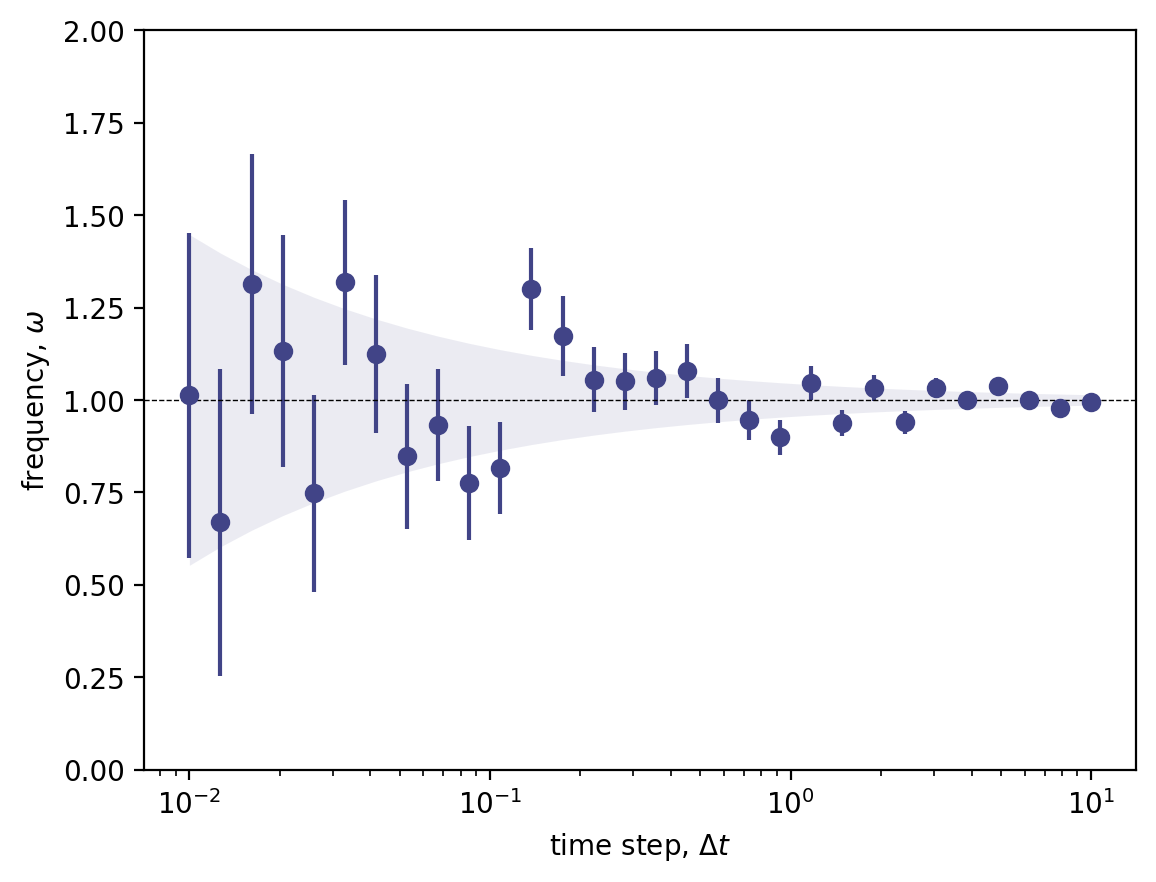

In [239]:
plt.fill_between(dts, omega + np.sqrt(2*Dtheta/((N-1)*dts)), 
                 omega - np.sqrt(2*Dtheta/((N-1)*dts)), 
                 color=cmap(0.2), alpha=0.1, lw=0)
plt.errorbar(dts, omegas, omega_errs, fmt='o', color=cmap(0.2))
plt.axhline(y=omega, color='k', lw=0.5, ls='--')
plt.ylim(0,2)
plt.xscale('log')
plt.xlabel(r'time step, $\Delta t$')
plt.ylabel(r'frequency, $\omega$');

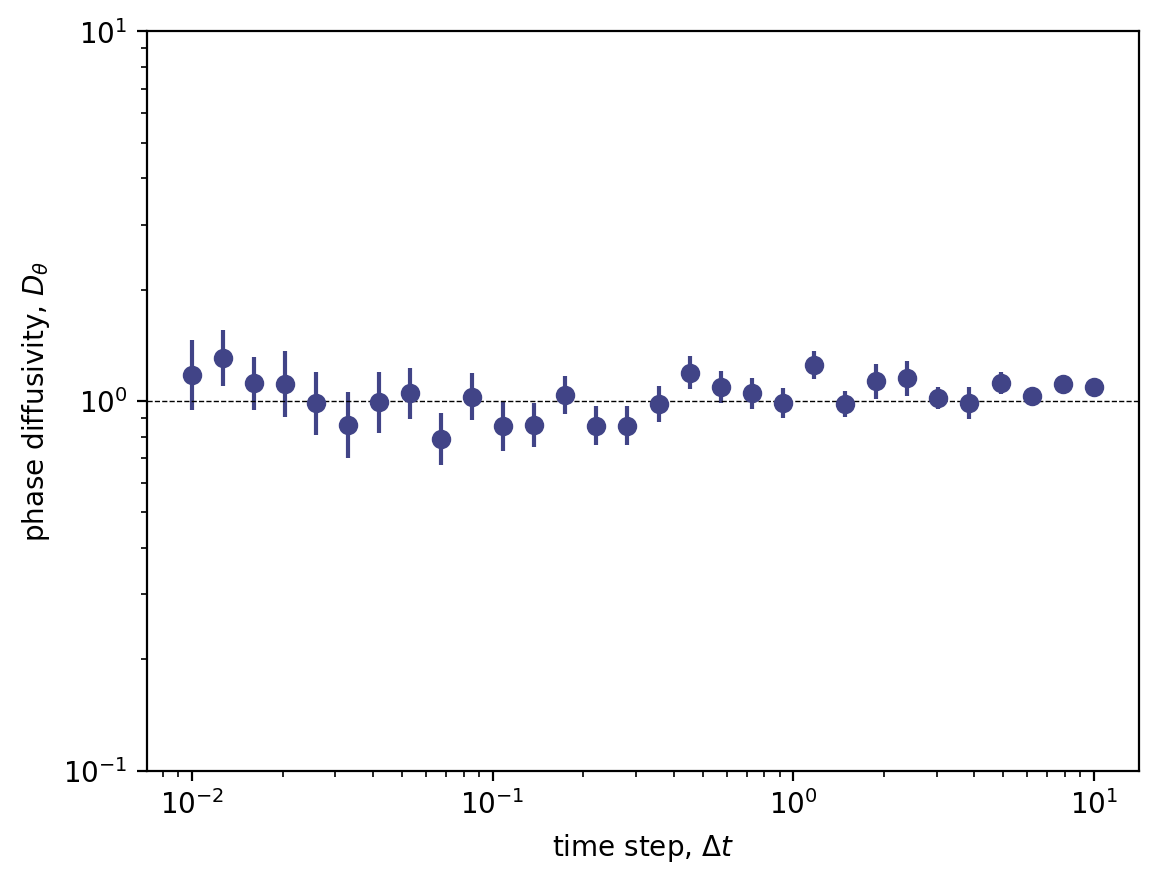

In [229]:
Dtheta_errs = np.vstack((Dthetas - np.exp(np.log(Dthetas) - lnDtheta_errs),
                         np.exp(np.log(Dthetas) + lnDtheta_errs) - Dthetas))
plt.errorbar(dts, Dthetas, Dtheta_errs, fmt='o', color=cmap(0.2))
plt.axhline(y=1, color='k', lw=0.5, ls='--')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'time step, $\Delta t$')
plt.ylim(0.1,10)
plt.ylabel(r'phase diffusivity, $D_\theta$');

## Effect of noise $R$

For constant $N$, $\Delta t$, $\theta_0$, $\omega$, $D_\theta$

In [268]:
# Model Parameters 
omega = 1.    # drift velocity
Dtheta = 1.  # phase diffusivity 
theta0 = 0.   # initial phase, radians
param = (theta0,omega,Dtheta,R)

# Simulation Parameters
N = 1000 # number of data points
dt = 1. # time step, seconds
    
R_points = 30
R_min = 1
R_max = 1000
Rs = np.logspace(np.log10(R_min), np.log10(R_max), R_points)
omegas  = np.zeros((R_points,))
omega_errs  = np.zeros((R_points,))
Dthetas  = np.zeros((R_points,))
lnDtheta_errs  = np.zeros((R_points,))

for j in range(R_points):
    param = (theta0, omega, Dtheta, Rs[j])
    lambda_map, lambda_cov = SPLM.simulate_and_infer(param, N, dt, rng, priors, N_samples=N_samples)
  
    omegas[j] = lambda_map[1]
    omega_errs[j] = np.sqrt(lambda_cov[1,1])

    Dthetas[j] = lambda_map[2]
    lnDtheta_errs[j] = np.sqrt(lambda_cov[2,2])

/var/folders/3t/kzggq_pj18sb06fbx03gw2pr0000gn/T/ipykernel_62466/3809314907.py:28: RuntimeWarning: invalid value encountered in sqrt
  lnDtheta_errs[j] = np.sqrt(lambda_cov[2,2])


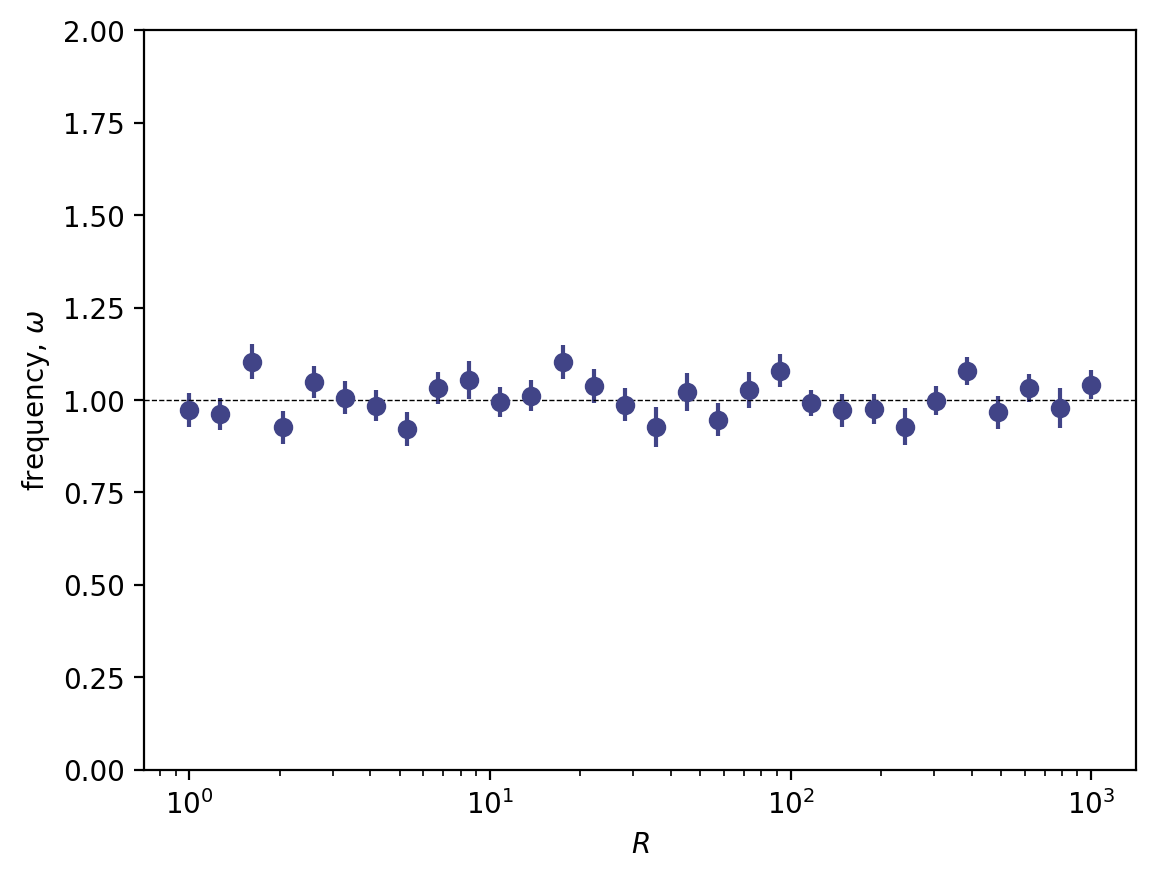

In [271]:
plt.errorbar(Rs, omegas, omega_errs, fmt='o', color=cmap(0.2))
plt.axhline(y=1, color='k', lw=0.5, ls='--')
plt.ylim(0,2)
plt.xscale('log')
plt.xlabel('$R$')
plt.ylabel(r'frequency, $\omega$');

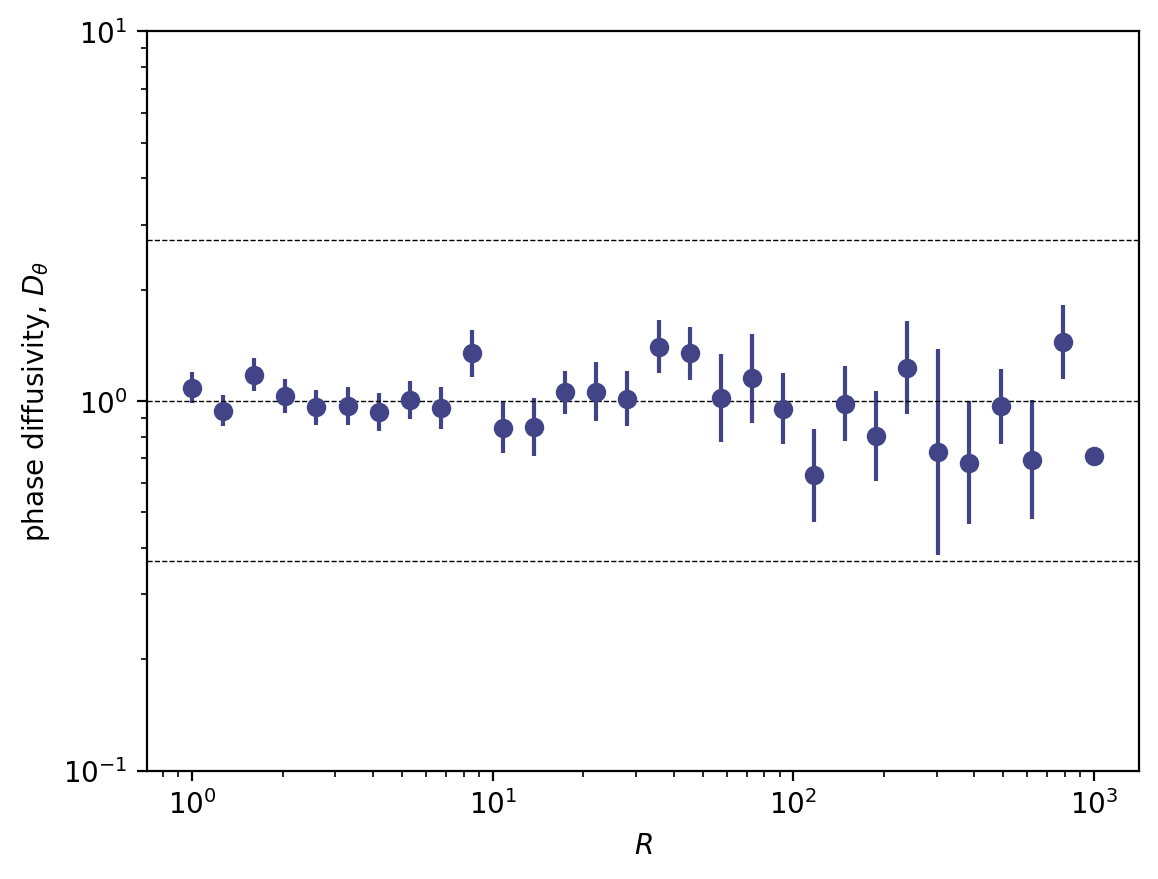

In [273]:
Dtheta_errs = np.vstack((Dthetas - np.exp(np.log(Dthetas) - lnDtheta_errs),
                         np.exp(np.log(Dthetas) + lnDtheta_errs) - Dthetas))
plt.errorbar(Rs, Dthetas, Dtheta_errs, fmt='o', color=cmap(0.2))

# prior
plt.axhline(y=np.exp(np.log(beta_D/(1+alpha_D)) + 1/(alpha_D+1)), color='k', lw=0.5, ls='--')
plt.axhline(y=np.exp(np.log(beta_D/(1+alpha_D)) - 1/(alpha_D+1)), color='k', lw=0.5, ls='--')

plt.axhline(y=1, color='k', lw=0.5, ls='--')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$R$')
plt.ylim(0.1,10)
plt.ylabel(r'phase diffusivity, $D_\theta$');

In [74]:
def monte_carlo_trials(param, N, dt, priors, M=100, seed=None):
    """
    Run M synthetic realizations and collect MAP estimates
    and Laplace covariance estimates.

    Returns
    -------
    results : dict
        {
            "map": array (M, 4),
            "sd": array (M, 4),
            "cov": array (M, 4, 4),
            "error": array (M, 4),
            "rmse": array (4,),
            "median_sd": array (4,)
        }
    """

    rng = np.random.default_rng(seed)

    map_estimates = np.zeros((M, 4))
    sd_estimates  = np.zeros((M, 4))
    cov_estimates = np.zeros((M, 4, 4))

    true_param = np.array(param)

    for m in range(M):
        lambda_map, lambda_cov = SPLM.simulate_and_infer(
            param, N, dt, rng, priors
        )

        map_estimates[m] = lambda_map
        cov_estimates[m] = lambda_cov
        sd_estimates[m]  = np.sqrt(np.diag(lambda_cov))

    errors = map_estimates - true_param

    rmse = np.sqrt(np.mean(errors**2, axis=0))
    median_sd = np.median(sd_estimates, axis=0)

    return {
        "map": map_estimates,
        "sd": sd_estimates,
        "cov": cov_estimates,
        "error": errors,
        "rmse": rmse,
        "median_sd": median_sd
    }

In [67]:
output = monte_carlo_trials(param, N, dt, priors, M=10, seed=123)

In [88]:
output['median_sd']

array([0.23727744, 0.06754457, 0.19945864, 0.05167207])

In [90]:
theta0 = 0
omega = 1
Dtheta = 1
N = 1000
gamma = 0.1
R = N/(3*gamma**2)
param = (theta0, omega, Dtheta, R)

# vary time step
dt_c = 6*R/N**2
dt_min = gamma*dt_c
dt_max = dt_c/gamma
points = 10;
dts = np.logspace(np.log(dt_min), np.log(dt_max), points, base=np.exp(1))

In [91]:
omega_sd = np.zeros((points,))
M = 5

for j in range(points):
    print(j)
    res = monte_carlo_trials(param, N, dts[j], priors, M, seed=None)
    omega_sd[j] = res['median_sd'][1]

0


/var/folders/3t/kzggq_pj18sb06fbx03gw2pr0000gn/T/ipykernel_62466/345933233.py:34: RuntimeWarning: invalid value encountered in sqrt
  sd_estimates[m]  = np.sqrt(np.diag(lambda_cov))


1
2
3
4
5
6
7
8
9


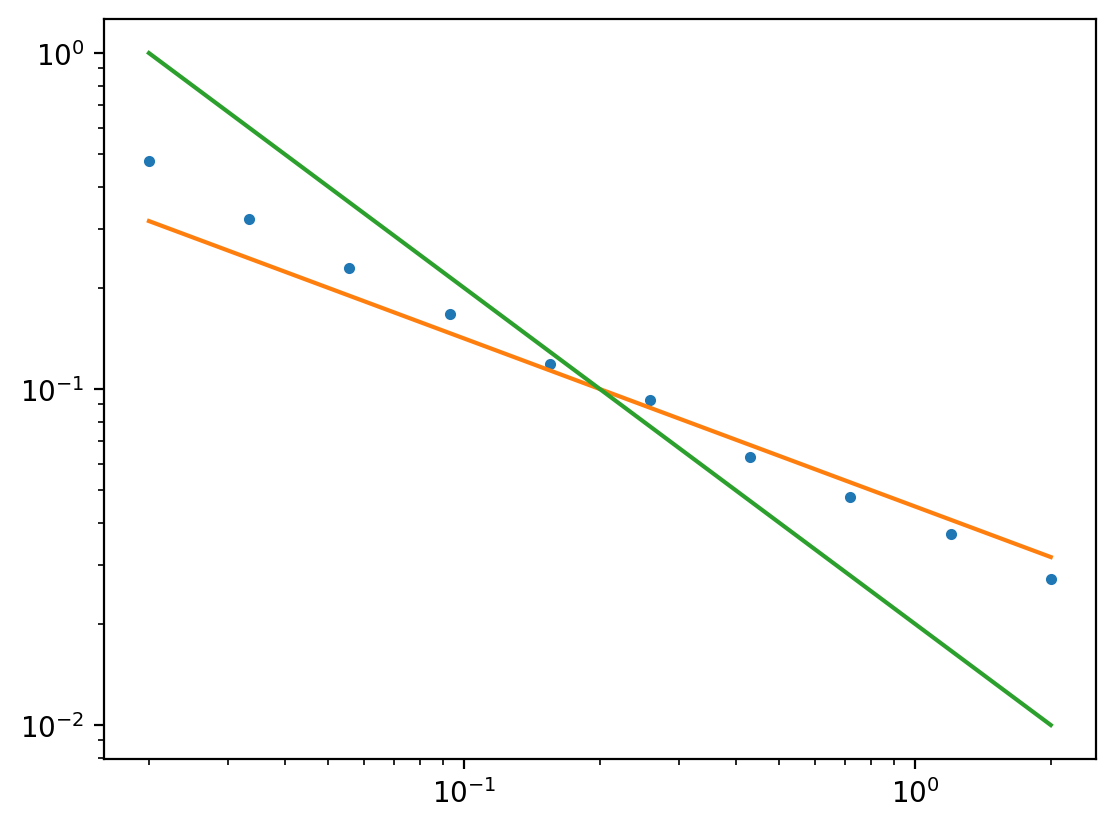

In [96]:
plt.loglog(dts, omega_sd, '.')
plt.loglog(dts, np.sqrt(2/(N*dts)), '-')
plt.loglog(dts,  np.sqrt(12*R/(N**3 * dts**2)), '-')

In [ ]:
theta0 = 0
omega = 1
Dtheta = 1
N = 100
gamma = 0.1
R = N/(3*gamma**2)
param = (theta0, omega, Dtheta, R)

# vary time step
dt_c = 6*R/N**2
dt_min = gamma*dt_c
dt_max = dt_c/gamma
points = 10;
dts = np.logspace(np.log(dt_min), np.log(dt_max), points, base=np.exp(1))

omega_sd = np.zeros((points,))
M = 5

for j in range(points):
    print(j)
    res = monte_carlo_trials(param, N, dts[j], priors, M, seed=None)
    omega_sd[j] = res['median_sd'][1]